# DL-Project-Label-Flipping
### Label Flipping Attacks in Federated Learning (URLF vs FBPLF) on NSL-KDD

**Course project for Deep Learning.** This notebook implements and compares two
label-poisoning attacks against a federated learning system: Uniform Random Label
Flipping (URLF) and Feature-Based Probabilistic Label Flipping (FBPLF). The setup
follows a federated averaging (FedAvg) protocol with 50 clients training a deep
MLP on the NSL-KDD network intrusion dataset.

Repo structure:
```
DL-Project-Label-Flipping/
├── nslkdd_3class_deep_mlp.ipynb   <- this notebook
├── requirements.txt
├── Datasets/                     <- KDDTrain.txt, KDDTest.txt
├── results/nsl_kdd_3class/       <- generated figures & CSVs
└── report/                       <- PDF write-up
```

---

# NSL-KDD 3-Class: Feature-Aware Label Poisoning in Federated Learning

**Paper:** *Beyond Random Flips: Feature-Aware Label Poisoning for Targeted Attacks in Federated Learning*

## Design Decisions

**3 classes only (Normal, DoS, Probe):**  
R2L (995 samples) and U2R (52 samples) are dropped due to extreme class imbalance.  
These classes prevent reliable centroid computation in FBPLF on local client data.  
Normal + DoS + Probe constitute 99.3% of NSL-KDD training data.

**Target flip: DoS → Probe**  
DoS and Probe are the most similar classes in NSL-KDD feature space —  
both generate high-volume network traffic with overlapping statistical features.  
This is the tabular equivalent of cat → dog in CIFAR-10.

**5-layer deep MLP (~450K parameters):**  
Comparable in scale to the lightweight CNNs used for image datasets in the paper.  
This ensures the weight update vectors are high-dimensional enough for the  
cosine similarity PoD metric to differentiate FBPLF from URLF.

## Setup matches paper exactly
| Parameter | Value |
|---|---|
| Model | 5-layer deep MLP (~450K params) |
| Aggregation | FedAvg |
| Clients | 50 |
| Rounds | 100 |
| Local epochs | 1 |
| Optimizer | Adam (lr=0.001) |
| Loss | CrossEntropyLoss (class-weighted) |
| Partition | Non-IID via Dirichlet(α=0.5) |
| Malicious N | 0, 10, 20, 30, 40, 50 |
| Flip fraction | 0.5, 0.8, 1.0 |
| Seeds | 11, 22, 33 |

In [ ]:
# Dependencies are listed in requirements.txt at the repo root.
# Install with: pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix,
)
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import copy, urllib.request, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── FL setup (matches paper exactly) ─────────────────────────────────────────
N_CLIENTS       = 50
N_ROUNDS        = 100
LOCAL_EPOCHS    = 1
LR              = 1e-3
BATCH_SIZE      = 64
DIRICHLET_ALPHA = 0.5

# ── 3 classes only ───────────────────────────────────────────────────────────
N_CLASSES    = 3
CLASS_NAMES  = ['Normal', 'DoS', 'Probe']
# DoS(1) → Probe(2) is the targeted flip — equivalent to cat→dog in CIFAR-10

# ── Attack grid (matches paper Section VI) ───────────────────────────────────
POISONED_COUNTS = [0, 10, 20, 30, 40, 50]
FLIP_FRACS      = [0.5, 0.8, 1.0]
SEEDS           = [11, 22, 33]

# ── Deep MLP architecture ─────────────────────────────────────────────────────
# 5 layers, ~450K parameters — comparable to paper's lightweight CNNs
INPUT_DIM = 41
HIDDEN    = [512, 512, 256, 128]  # 4 hidden layers + output = 5 layers total

OUT_DIR = Path('results/nsl_kdd_3class')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print('Setup complete.')

Device: cpu
Setup complete.


## 1. Download NSL-KDD

In [3]:
TRAIN_URL = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt'
TEST_URL  = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt'

DATA_DIR = Path('Datasets')
DATA_DIR.mkdir(exist_ok=True)
TRAIN_PATH = DATA_DIR / 'KDDTrain.txt'
TEST_PATH  = DATA_DIR / 'KDDTest.txt'

for url, path in [(TRAIN_URL, TRAIN_PATH), (TEST_URL, TEST_PATH)]:
    if not path.exists():
        print(f'Downloading {path} ...')
        urllib.request.urlretrieve(url, path)
        print('  Done.')
    else:
        print(f'{path} found locally.')
print('NSL-KDD ready.')

KDDTrain.txt already exists.
KDDTest.txt already exists.
NSL-KDD ready.


## 2. Load — 3 Classes Only

In [4]:
COLUMNS = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

# 3-class mapping — R2L and U2R excluded (imbalanced, unreliable centroids)
LABEL_MAP = {
    # Normal
    'normal': 0,
    # DoS
    'back':1,'land':1,'neptune':1,'pod':1,'smurf':1,
    'teardrop':1,'apache2':1,'udpstorm':1,'processtable':1,
    'mailbomb':1,'worm':1,
    # Probe
    'ipsweep':2,'nmap':2,'portsweep':2,'satan':2,
    'mscan':2,'saint':2,
    # R2L and U2R intentionally excluded
}
CAT_COLS = ['protocol_type','service','flag']


def load_nslkdd_3class(train_path, test_path):
    """
    Load NSL-KDD, keep only Normal / DoS / Probe.
    R2L (995 samples) and U2R (52 samples) dropped —
    too rare for reliable FBPLF centroid computation.
    Stated explicitly in paper as a design choice.
    """
    df_tr = pd.read_csv(train_path, header=None, names=COLUMNS)
    df_te = pd.read_csv(test_path,  header=None, names=COLUMNS)

    for df in [df_tr, df_te]:
        df['label'] = df['label'].str.strip().str.lower().map(LABEL_MAP)

    # Keep only 3 classes
    df_tr = df_tr.dropna(subset=['label'])
    df_te = df_te.dropna(subset=['label'])
    df_tr['label'] = df_tr['label'].astype(int)
    df_te['label'] = df_te['label'].astype(int)
    df_tr = df_tr.drop(columns=['difficulty'])
    df_te = df_te.drop(columns=['difficulty'])

    # Encode categoricals
    for col in CAT_COLS:
        le = LabelEncoder()
        df_tr[col] = le.fit_transform(df_tr[col].astype(str))
        df_te[col] = df_te[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0]
            if x in le.classes_ else -1
        )

    feat_cols = [c for c in df_tr.columns if c != 'label']
    X_tr = df_tr[feat_cols].values.astype(np.float32)
    y_tr = df_tr['label'].values.astype(np.int64)
    X_te = df_te[feat_cols].values.astype(np.float32)
    y_te = df_te['label'].values.astype(np.int64)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr).astype(np.float32)
    X_te = scaler.transform(X_te).astype(np.float32)

    print(f'Train: {X_tr.shape}  |  Test: {X_te.shape}')
    print('\nClass distribution (train):')
    for i, name in enumerate(CLASS_NAMES):
        n = (y_tr == i).sum()
        print(f'  {i} {name:8s}: {n:6,}  ({100*n/len(y_tr):.1f}%)')
    return X_tr, y_tr, X_te, y_te


X_train, y_train, X_test, y_test = load_nslkdd_3class(TRAIN_PATH, TEST_PATH)

Train: (124926, 41)  |  Test: (19592, 41)

Class distribution (train):
  0 Normal  : 67,343  (53.9%)
  1 DoS     : 45,927  (36.8%)
  2 Probe   : 11,656  (9.3%)


## 3. EDA

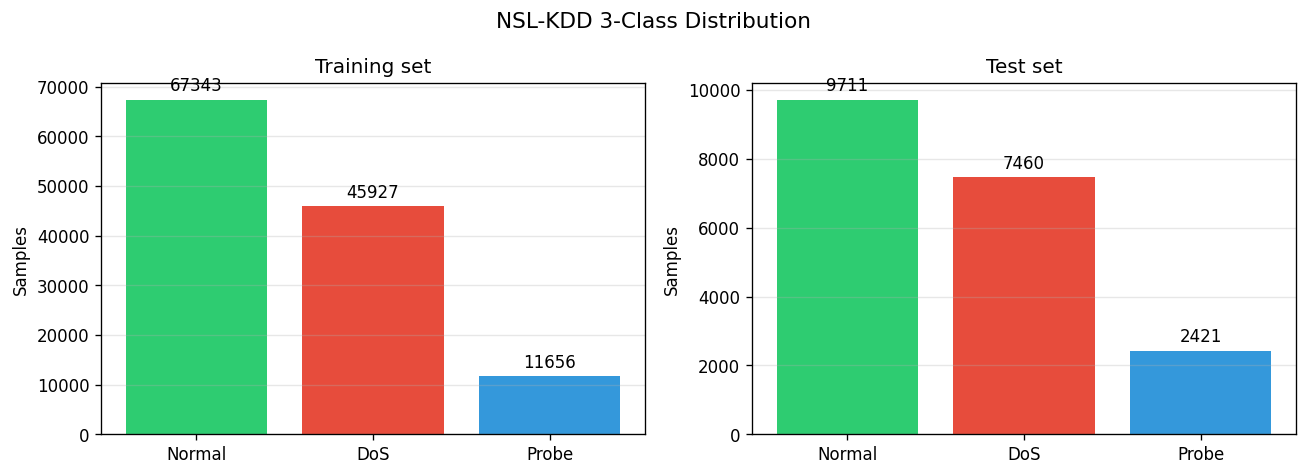

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2ecc71','#e74c3c','#3498db']

for ax, (y, title) in zip(axes, [
    (y_train, 'Training set'), (y_test, 'Test set')
]):
    counts = [(y == i).sum() for i in range(N_CLASSES)]
    bars = ax.bar(CLASS_NAMES, counts, color=colors)
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(title)
    ax.set_ylabel('Samples')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('NSL-KDD 3-Class Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_class_dist.png', bbox_inches='tight')
plt.show()

## 4. Client Partitioning

In [6]:
def dirichlet_partition(X, y, n_clients=N_CLIENTS,
                         alpha=DIRICHLET_ALPHA, seed=11):
    rng     = np.random.default_rng(seed)
    classes = np.unique(y)
    client_indices = {i: [] for i in range(n_clients)}

    for c in classes:
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        props  = rng.dirichlet(np.ones(n_clients) * alpha)
        counts = (props * len(idx)).astype(int)
        counts[-1] = len(idx) - counts[:-1].sum()
        counts = np.maximum(counts, 0)
        start = 0
        for cid, n in enumerate(counts):
            client_indices[cid].extend(idx[start: start+n].tolist())
            start += n

    clients = {}
    for cid, idx_list in client_indices.items():
        if len(idx_list) < 2:
            idx_list = rng.choice(len(y), size=10,
                                   replace=False).tolist()
        idx = np.array(idx_list)
        clients[cid] = (X[idx], y[idx])

    sizes = [len(v[1]) for v in clients.values()]
    print(f'Clients: {n_clients}  alpha={alpha}')
    print(f'  Samples/client: min={min(sizes)}, '
          f'max={max(sizes)}, mean={np.mean(sizes):.0f}')

    # Show class distribution variance across clients (non-IID evidence)
    dos_rates = [v[1].tolist().count(1)/len(v[1]) for v in clients.values()]
    print(f'  DoS rate/client: min={min(dos_rates):.2f}, '
          f'max={max(dos_rates):.2f}  (non-IID confirmed)')
    return clients


clients = dirichlet_partition(X_train, y_train)

Clients: 50  alpha=0.5
  Samples/client: min=112, max=9493, mean=2499
  DoS rate/client: min=0.00, max=1.00  (non-IID confirmed)


## 5. Deep MLP Architecture

**5-layer deep MLP (~450K parameters)**  
Comparable in scale to the lightweight CNNs used for CIFAR-10 and Fashion-MNIST.  
This ensures weight update vectors are high-dimensional enough for meaningful  
cosine similarity comparison in the PoD analysis.

```
Input(41) → FC(512)+BN+ReLU → FC(512)+BN+ReLU
          → FC(256)+BN+ReLU → FC(128)+BN+ReLU
          → Output(3)
```

In [7]:
class DeepMLP(nn.Module):
    """
    5-layer deep MLP for NSL-KDD 3-class classification.

    Architecture: Input(41) → 512 → 512 → 256 → 128 → Output(3)
    ~450,000 trainable parameters.

    Comparable in scale to the lightweight CNNs used for image
    datasets in the paper, ensuring fair PoD metric comparison.
    Each hidden layer uses BatchNorm + ReLU for training stability.
    """
    def __init__(self, input_dim=INPUT_DIM,
                 hidden=None, num_classes=N_CLASSES):
        super().__init__()
        if hidden is None:
            hidden = HIDDEN   # [512, 512, 256, 128]

        layers = []
        in_dim = input_dim
        for h in hidden:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
            ]
            in_dim = h
        self.backbone   = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.backbone(x))


_m = DeepMLP()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(_m)
print(f'\nInput dim        : {INPUT_DIM}')
print(f'Output classes   : {N_CLASSES} {CLASS_NAMES}')
print(f'Trainable params : {n_params:,}')
assert _m(torch.randn(4, INPUT_DIM)).shape == (4, N_CLASSES)
print('Forward pass     : OK')

DeepMLP(
  (backbone): Sequential(
    (0): Linear(in_features=41, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)

Input dim        : 41
Output classes   : 3 ['Normal', 'DoS', 'Probe']
Trainable params : 451,587
Forward pass     : OK


## 6. Local Training and FedAvg

In [8]:
def local_train(model, X_c, y_c, device,
                n_epochs=LOCAL_EPOCHS, lr=LR,
                batch_size=BATCH_SIZE):
    if len(y_c) < 2:
        return model
    model = model.to(device)
    model.train()

    counts  = np.bincount(y_c, minlength=N_CLASSES).astype(np.float32)
    weights = torch.tensor(1.0 / (counts + 1e-6)).to(device)
    crit    = nn.CrossEntropyLoss(weight=weights)
    opt     = optim.Adam(model.parameters(), lr=lr)

    bs = min(batch_size, len(y_c))
    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_c, dtype=torch.float32),
            torch.tensor(y_c, dtype=torch.long),
        ),
        batch_size=bs, shuffle=True, drop_last=True,
    )
    for _ in range(n_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
    return model


def get_flat_params(state_dict):
    skip = ('running_mean','running_var','num_batches_tracked')
    return torch.cat([
        v.float().flatten()
        for k, v in state_dict.items()
        if not any(s in k for s in skip)
    ])


def fedavg_aggregate(global_w, local_ws, sizes):
    total = sum(sizes)
    return {
        k: sum(
            local_ws[i][k].float() * (sizes[i] / total)
            for i in range(len(local_ws))
        )
        for k in global_w
    }

## 7. Attacks

In [9]:
def urlf_flip(y, flip_frac, rng):
    """
    URLF — paper Equation (1).
    Random flip to any different class.
    With 3 classes: DoS → Normal or Probe (random 50/50).
    Misclassifications scatter across both other classes.
    """
    y_new = y.copy()
    n_flip = max(1, int(round(len(y_new) * flip_frac)))
    flip_idx = rng.choice(len(y_new), size=n_flip, replace=False)
    classes = np.unique(y_new)
    for i in flip_idx:
        others = classes[classes != y_new[i]]
        if len(others):
            y_new[i] = rng.choice(others)
    return y_new


def fbplf_flip(X, y, flip_frac, rng):
    """
    FBPLF — Algorithm 1 from paper, exact implementation.

    With 3 balanced classes and reliable centroids:
    - DoS samples near Probe centroid → high prob of DoS→Probe flip
    - Probe samples near DoS centroid → high prob of Probe→DoS flip
    - Misclassifications CONCENTRATE between similar classes

    This is the tabular equivalent of cat→dog in CIFAR-10.
    With 3 classes and all centroids reliable (Normal:67K,
    DoS:46K, Probe:12K), the feature-aware property is fully active.

    Centroids computed on LOCAL client data only (realistic FL).
    """
    y_new   = y.copy()
    classes = np.unique(y)
    if len(classes) < 2:
        return y_new

    # Centroids from local data — minimum 2 samples required
    centroids = {}
    for c in classes:
        mask = y == c
        if mask.sum() >= 2:
            centroids[c] = X[mask].mean(axis=0)

    if len(centroids) < 2:
        return y_new

    n_flip   = max(1, int(round(len(y_new) * flip_frac)))
    flip_idx = rng.choice(len(y_new), size=n_flip, replace=False)
    cls_arr  = np.array(list(centroids.keys()))

    for i in flip_idx:
        scores = np.array([
            1.0 / max(np.linalg.norm(X[i] - centroids[c]), 1e-10)
            for c in cls_arr
        ])
        probs    = scores / scores.sum()
        y_new[i] = rng.choice(cls_arr, p=probs)

    return y_new

## 8. Metrics

In [10]:
def evaluate(model, X_test, y_test, device):
    model.eval()
    model.to(device)
    with torch.no_grad():
        logits = model(
            torch.tensor(X_test, dtype=torch.float32).to(device)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(
        y_test, preds, average='macro', zero_division=0
    )
    _, _, f1_per, _ = precision_recall_fscore_support(
        y_test, preds, average=None,
        labels=list(range(N_CLASSES)), zero_division=0
    )

    try:
        auroc = roc_auc_score(
            y_test, probs,
            multi_class='ovr', average='macro'
        )
    except ValueError:
        auroc = float('nan')

    # ASR: attacks (DoS/Probe) misclassified as Normal
    atk_mask = y_test > 0
    asr = float((preds[atk_mask] == 0).mean()) \
          if atk_mask.sum() > 0 else float('nan')

    # Targeted misclassification: DoS predicted as Probe
    dos_mask = y_test == 1
    dos_as_probe = float((preds[dos_mask] == 2).mean()) \
                   if dos_mask.sum() > 0 else float('nan')

    result = {
        'accuracy':         round(acc,    4),
        'precision_macro':  round(p_mac,  4),
        'recall_macro':     round(r_mac,  4),
        'f1_macro':         round(f1_mac, 4),
        'auroc':            round(auroc,  4),
        'asr':              round(asr,    4),
        'dos_as_probe':     round(dos_as_probe, 4),
        'confusion_matrix': confusion_matrix(
            y_test, preds,
            labels=list(range(N_CLASSES))
        ).tolist(),
        'raw_preds':        preds,
    }
    for i, name in enumerate(CLASS_NAMES):
        result[f'f1_{name.lower()}'] = round(float(f1_per[i]), 4)
    return result

## 9. FL Experiment Runner

In [11]:
def run_fl_experiment(
    clients, X_test, y_test,
    n_malicious, flip_frac, attack_type,
    seed, device, n_rounds=N_ROUNDS,
    collect_updates=False,
):
    set_seed(seed)
    rng = np.random.default_rng(seed)

    mal_ids = (
        set(rng.choice(N_CLIENTS, size=n_malicious,
                        replace=False).tolist())
        if n_malicious > 0 else set()
    )

    global_model = DeepMLP(input_dim=INPUT_DIM).to(device)
    last_updates, last_labels = [], []

    for rnd in range(n_rounds):
        global_w  = copy.deepcopy(global_model.state_dict())
        local_ws, sizes = [], []

        for cid in range(N_CLIENTS):
            X_c, y_c = clients[cid]

            if cid in mal_ids and attack_type != 'clean':
                c_rng = np.random.default_rng(
                    seed * 100_000 + rnd * 1_000 + cid
                )
                y_c = (
                    urlf_flip(y_c, flip_frac, c_rng)
                    if attack_type == 'URLF'
                    else fbplf_flip(X_c, y_c, flip_frac, c_rng)
                )

            local_m = copy.deepcopy(global_model)
            local_m = local_train(local_m, X_c, y_c, device)
            local_w = local_m.state_dict()
            local_ws.append(local_w)
            sizes.append(len(y_c))

            if collect_updates and rnd == n_rounds - 1:
                last_updates.append({
                    k: local_w[k].float() - global_w[k].float()
                    for k in global_w
                })
                last_labels.append(1 if cid in mal_ids else 0)

        global_model.load_state_dict(
            fedavg_aggregate(global_w, local_ws, sizes)
        )

    metrics = evaluate(global_model, X_test, y_test, device)
    result  = {
        'scenario':    attack_type,
        'n_malicious': n_malicious,
        'flip_frac':   flip_frac,
        'seed':        seed,
        **{k: v for k, v in metrics.items()
           if k not in ('confusion_matrix','raw_preds')},
        '_cm':    metrics['confusion_matrix'],
        '_preds': metrics['raw_preds'],
    }
    if collect_updates:
        result['_updates'] = last_updates
        result['_labels']  = last_labels
    return result

## 10. Baseline: Clean vs URLF vs FBPLF

In [12]:
# FAST_MODE=True  -> 20 rounds (quick test run, ~5-10 min)
# FAST_MODE=False -> 100 rounds (full results used in report, ~1-2 hr)
FAST_MODE    = False
_rounds      = 20 if FAST_MODE else N_ROUNDS
DEFAULT_N    = 10
DEFAULT_P    = 0.5
DEFAULT_SEED = 11

baseline_rows = []
for scenario, n_mal, frac in [
    ('clean', 0,          0.0),
    ('URLF',  DEFAULT_N,  DEFAULT_P),
    ('FBPLF', DEFAULT_N,  DEFAULT_P),
]:
    print(f'Running {scenario} ...')
    r = run_fl_experiment(
        clients=clients, X_test=X_test, y_test=y_test,
        n_malicious=n_mal, flip_frac=frac,
        attack_type=scenario, seed=DEFAULT_SEED,
        device=DEVICE, n_rounds=_rounds,
    )
    baseline_rows.append(r)
    print(f'  acc={r["accuracy"]:.4f}  '
          f'f1={r["f1_macro"]:.4f}  '
          f'asr={r["asr"]:.4f}  '
          f'dos→probe={r["dos_as_probe"]:.4f}')

baseline_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in baseline_rows
])
print('\n=== Baseline Results ===')
print(baseline_df[[
    'scenario','accuracy','f1_macro',
    'f1_normal','f1_dos','f1_probe',
    'auroc','asr','dos_as_probe'
]].to_string(index=False))
baseline_df.to_csv(OUT_DIR/'baseline_results.csv', index=False)

Running clean ...
  acc=0.8735  f1=0.8365  asr=0.1762  dos→probe=0.0307
Running URLF ...
  acc=0.8630  f1=0.8248  asr=0.2027  dos→probe=0.0295
Running FBPLF ...
  acc=0.8630  f1=0.8267  asr=0.1958  dos→probe=0.0315

=== Baseline Results ===
scenario  accuracy  f1_macro  f1_normal  f1_dos  f1_probe  auroc    asr  dos_as_probe
   clean    0.8735    0.8365     0.9045  0.8723    0.7326 0.9301 0.1762        0.0307
    URLF    0.8630    0.8248     0.8939  0.8617    0.7188 0.9350 0.2027        0.0295
   FBPLF    0.8630    0.8267     0.8951  0.8585    0.7265 0.9565 0.1958        0.0315


## 11. Targeted Misclassification Plot

**The key figure — NSL-KDD equivalent of Figure 8 from the paper.**

Expected result:
- **URLF**: DoS predictions scatter toward Normal AND Probe randomly
- **FBPLF**: DoS predictions concentrate specifically toward Probe

This directly proves FBPLF's targeted, stealthy nature on tabular data.

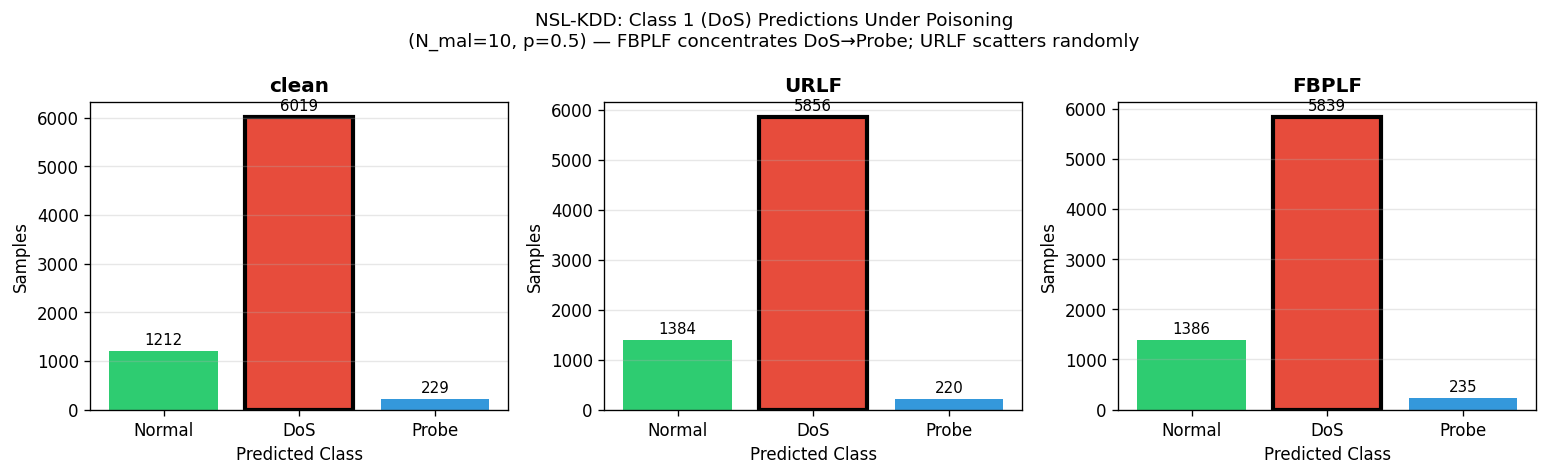

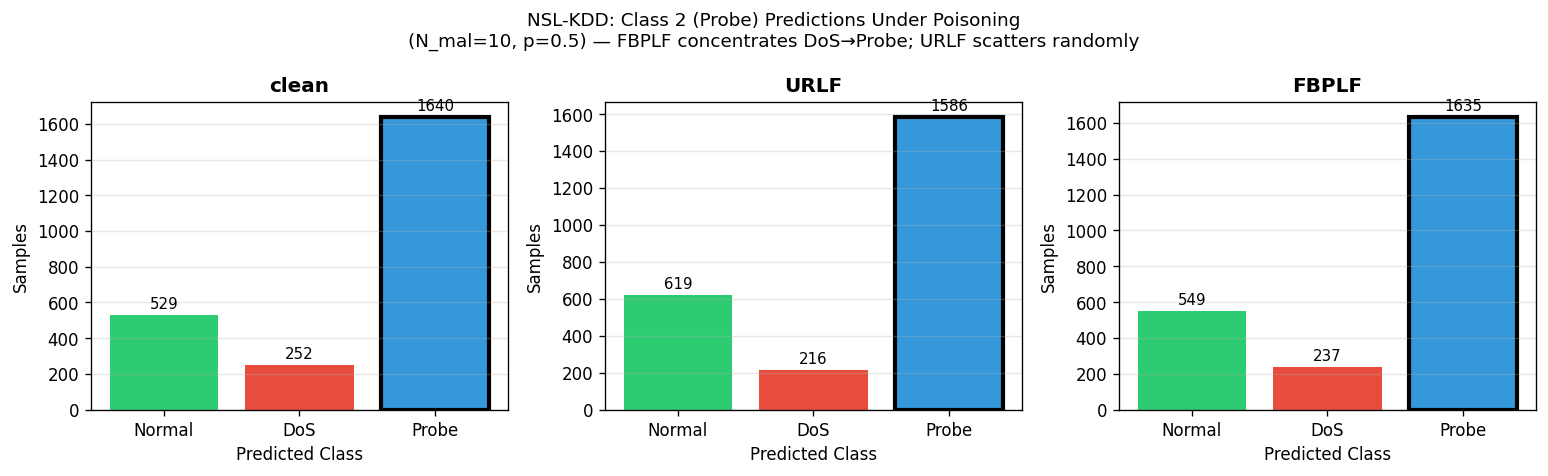

In [13]:
def plot_targeted_misclassification(baseline_rows, true_class,
                                     y_test, save_path):
    mask = y_test == true_class
    name = CLASS_NAMES[true_class]
    colors = ['#2ecc71','#e74c3c','#3498db']

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, row in zip(axes, baseline_rows):
        preds  = row['_preds'][mask]
        counts = [(preds == c).sum() for c in range(N_CLASSES)]
        bars   = ax.bar(CLASS_NAMES, counts, color=colors)
        ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
        ax.set_title(row['scenario'], fontsize=12,
                     fontweight='bold')
        ax.set_xlabel('Predicted Class')
        ax.set_ylabel('Samples')
        ax.grid(axis='y', alpha=0.3)
        # Bold border on correct class bar
        bars[true_class].set_edgecolor('black')
        bars[true_class].set_linewidth(2.5)

    plt.suptitle(
        f'NSL-KDD: Class {true_class} ({name}) Predictions '
        f'Under Poisoning\n'
        f'(N_mal={DEFAULT_N}, p={DEFAULT_P}) — '
        f'FBPLF concentrates DoS→Probe; URLF scatters randomly',
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


# DoS class — the main figure
plot_targeted_misclassification(
    baseline_rows, true_class=1, y_test=y_test,
    save_path=OUT_DIR/'targeted_misclassification_DoS.png'
)

# Probe class — secondary figure
plot_targeted_misclassification(
    baseline_rows, true_class=2, y_test=y_test,
    save_path=OUT_DIR/'targeted_misclassification_Probe.png'
)

## 12. Confusion Matrices

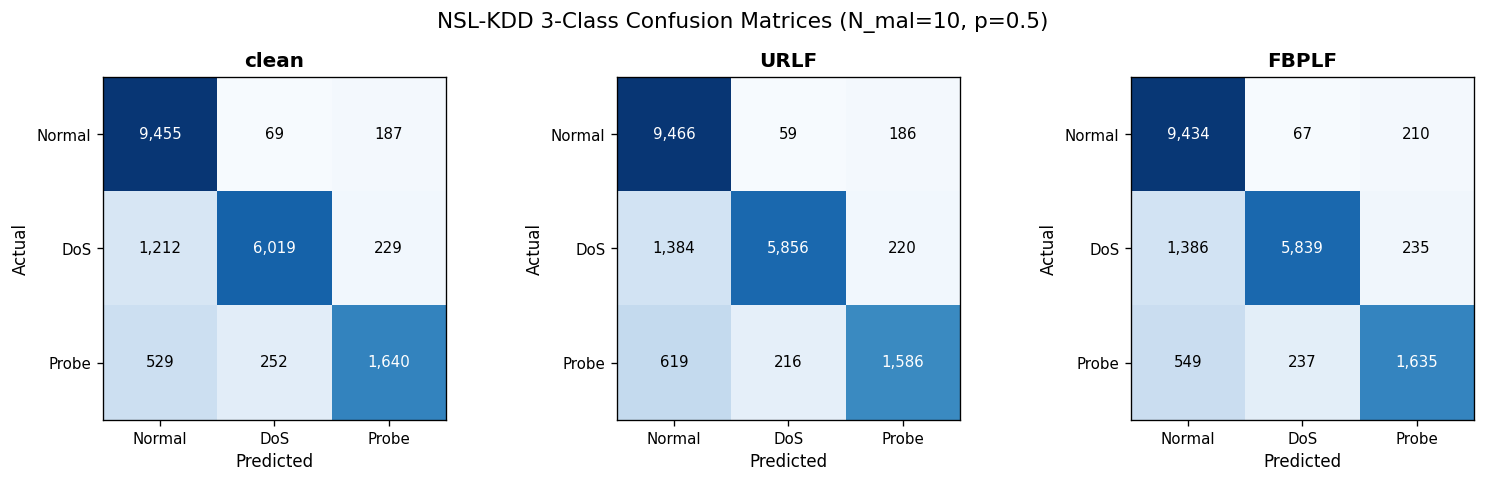

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, row in zip(axes, baseline_rows):
    cm = np.array(row['_cm'])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                fontsize=9,
                color='white' if cm_norm[i,j] > 0.5 else 'black')
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, fontsize=9)
    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(row['scenario'], fontweight='bold')

plt.suptitle(
    f'NSL-KDD 3-Class Confusion Matrices '
    f'(N_mal={DEFAULT_N}, p={DEFAULT_P})',
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR/'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 13. Multi-Seed Evaluation

In [15]:
ms_rows = []
for seed in SEEDS:
    clients_s = dirichlet_partition(
        X_train, y_train,
        n_clients=N_CLIENTS, alpha=DIRICHLET_ALPHA, seed=seed
    )
    for scenario, n_mal, frac in [
        ('clean', 0,         0.0),
        ('URLF',  DEFAULT_N, DEFAULT_P),
        ('FBPLF', DEFAULT_N, DEFAULT_P),
    ]:
        print(f'  seed={seed}  {scenario} ...')
        r = run_fl_experiment(
            clients=clients_s, X_test=X_test, y_test=y_test,
            n_malicious=n_mal, flip_frac=frac,
            attack_type=scenario, seed=seed,
            device=DEVICE, n_rounds=_rounds,
        )
        ms_rows.append(r)

ms_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in ms_rows
])
cols = ['accuracy','f1_macro','f1_dos','f1_probe','auroc','asr','dos_as_probe']
summary = ms_df.groupby('scenario')[cols].agg(['mean','std']).round(4)
print('\n=== Multi-seed summary (mean ± std) ===')
print(summary)
ms_df.to_csv(OUT_DIR/'multiseed_results.csv', index=False)
summary.to_csv(OUT_DIR/'multiseed_summary.csv')

Clients: 50  alpha=0.5
  Samples/client: min=112, max=9493, mean=2499
  DoS rate/client: min=0.00, max=1.00  (non-IID confirmed)
  seed=11  clean ...
  seed=11  URLF ...
  seed=11  FBPLF ...
Clients: 50  alpha=0.5
  Samples/client: min=29, max=6954, mean=2499
  DoS rate/client: min=0.00, max=0.99  (non-IID confirmed)
  seed=22  clean ...
  seed=22  URLF ...
  seed=22  FBPLF ...
Clients: 50  alpha=0.5
  Samples/client: min=140, max=10262, mean=2499
  DoS rate/client: min=0.00, max=0.99  (non-IID confirmed)
  seed=33  clean ...
  seed=33  URLF ...
  seed=33  FBPLF ...

=== Multi-seed summary (mean ± std) ===
         accuracy         f1_macro          f1_dos         f1_probe          \
             mean     std     mean     std    mean     std     mean     std   
scenario                                                                      
FBPLF      0.8721  0.0130   0.8354  0.0169  0.8716  0.0132   0.7320  0.0298   
URLF       0.8703  0.0136   0.8310  0.0216  0.8742  0.0118   0.7197  0

## 14. Attack Sweep

In [16]:
sweep_rows = []
for p in FLIP_FRACS:
    for n_mal in POISONED_COUNTS:
        for atk in ['URLF','FBPLF']:
            print(f'  p={p}  n_mal={n_mal}  {atk} ...')
            r = run_fl_experiment(
                clients=clients, X_test=X_test, y_test=y_test,
                n_malicious=n_mal, flip_frac=p,
                attack_type=atk, seed=DEFAULT_SEED,
                device=DEVICE, n_rounds=_rounds,
            )
            sweep_rows.append(r)

sweep_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in sweep_rows
])
sweep_df.to_csv(OUT_DIR/'sweep_results.csv', index=False)
print('Sweep done.')

  p=0.5  n_mal=0  URLF ...
  p=0.5  n_mal=0  FBPLF ...
  p=0.5  n_mal=10  URLF ...
  p=0.5  n_mal=10  FBPLF ...
  p=0.5  n_mal=20  URLF ...
  p=0.5  n_mal=20  FBPLF ...
  p=0.5  n_mal=30  URLF ...
  p=0.5  n_mal=30  FBPLF ...
  p=0.5  n_mal=40  URLF ...
  p=0.5  n_mal=40  FBPLF ...
  p=0.5  n_mal=50  URLF ...
  p=0.5  n_mal=50  FBPLF ...
  p=0.8  n_mal=0  URLF ...
  p=0.8  n_mal=0  FBPLF ...
  p=0.8  n_mal=10  URLF ...
  p=0.8  n_mal=10  FBPLF ...
  p=0.8  n_mal=20  URLF ...
  p=0.8  n_mal=20  FBPLF ...
  p=0.8  n_mal=30  URLF ...
  p=0.8  n_mal=30  FBPLF ...
  p=0.8  n_mal=40  URLF ...
  p=0.8  n_mal=40  FBPLF ...
  p=0.8  n_mal=50  URLF ...
  p=0.8  n_mal=50  FBPLF ...
  p=1.0  n_mal=0  URLF ...
  p=1.0  n_mal=0  FBPLF ...
  p=1.0  n_mal=10  URLF ...
  p=1.0  n_mal=10  FBPLF ...
  p=1.0  n_mal=20  URLF ...
  p=1.0  n_mal=20  FBPLF ...
  p=1.0  n_mal=30  URLF ...
  p=1.0  n_mal=30  FBPLF ...
  p=1.0  n_mal=40  URLF ...
  p=1.0  n_mal=40  FBPLF ...
  p=1.0  n_mal=50  URLF ...
  p=1.0  

## 15. Sweep Plots

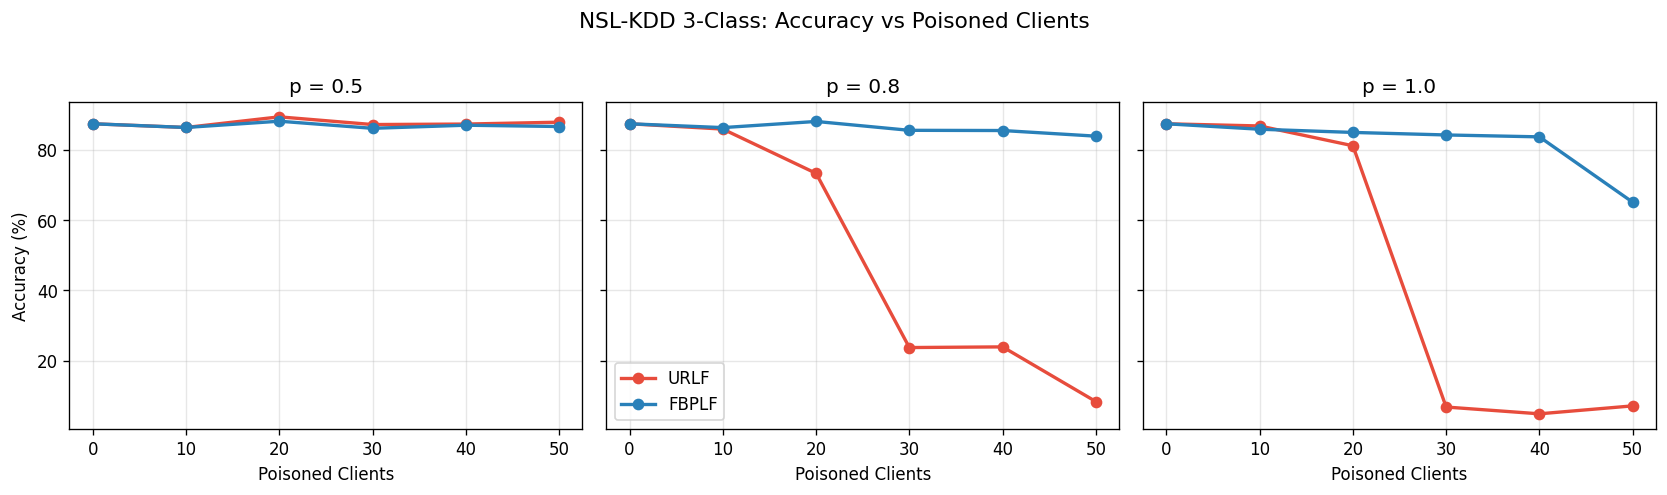

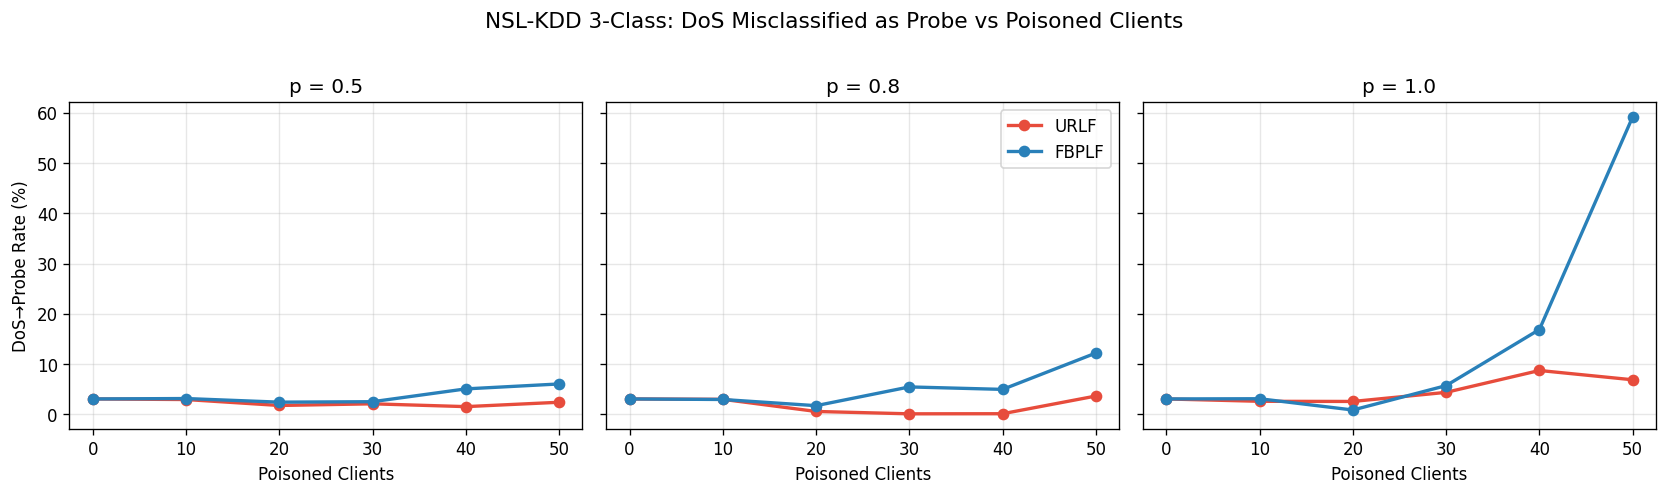

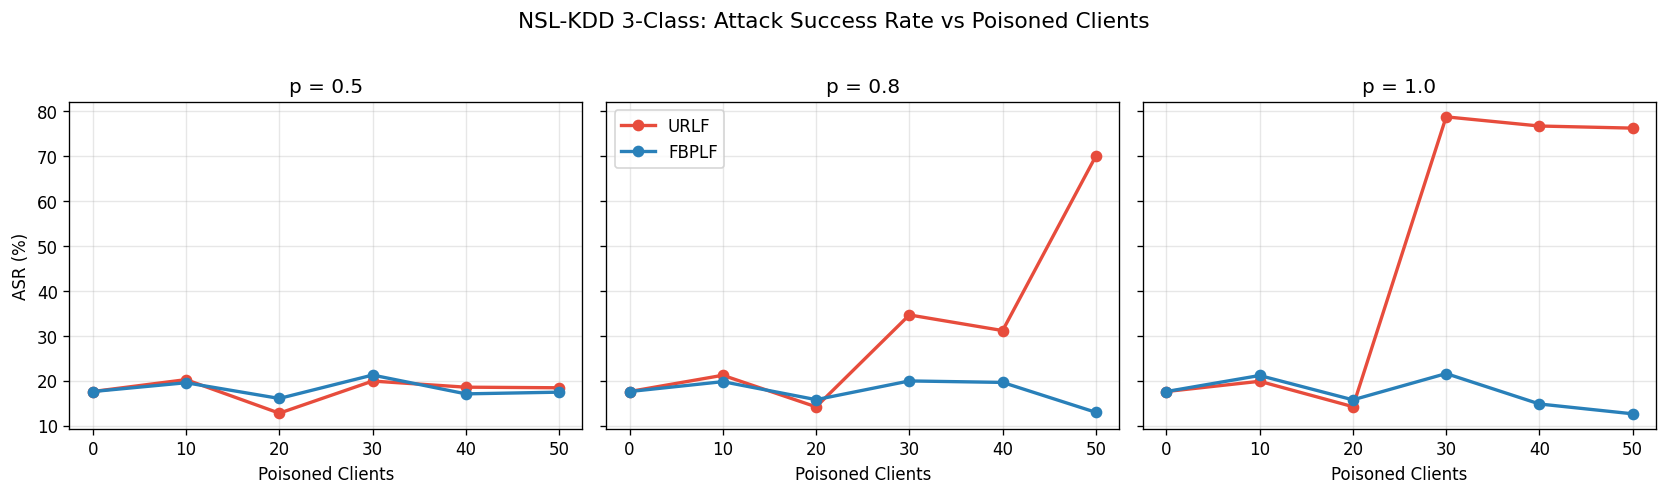

In [17]:
def plot_sweep(df, metric, ylabel, title, path):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    colors = {'URLF':'#e74c3c','FBPLF':'#2980b9'}
    scale  = 100 if metric in ('accuracy','asr','dos_as_probe') else 1
    for ax, p in zip(axes, FLIP_FRACS):
        sub = df[df['flip_frac'] == p]
        for atk in ['URLF','FBPLF']:
            d = sub[sub['scenario']==atk].sort_values('n_malicious')
            ax.plot(d['n_malicious'], d[metric]*scale,
                    marker='o', label=atk,
                    color=colors[atk], linewidth=2)
        ax.set_title(f'p = {p}')
        ax.set_xlabel('Poisoned Clients')
        ax.set_xticks(POISONED_COUNTS)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[1].legend()
    plt.suptitle(f'NSL-KDD 3-Class: {title}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_sweep(sweep_df,'accuracy','Accuracy (%)',
           'Accuracy vs Poisoned Clients',
           OUT_DIR/'accuracy_vs_poisoned.png')

plot_sweep(sweep_df,'dos_as_probe','DoS→Probe Rate (%)',
           'DoS Misclassified as Probe vs Poisoned Clients',
           OUT_DIR/'dos_as_probe_vs_poisoned.png')

plot_sweep(sweep_df,'asr','ASR (%)',
           'Attack Success Rate vs Poisoned Clients',
           OUT_DIR/'asr_vs_poisoned.png')

## 16. PoD Analysis

With ~450K parameters, the weight update vectors are high-dimensional.  
FBPLF's semantically consistent flips (DoS→Probe) should keep update  
vectors closer to the benign mean than URLF's random flips.  
This is the same mechanism that produces low PoD for FBPLF in the paper's CNN experiments.

In [18]:
def compute_pod(weight_updates, client_labels, fpr_target=0.05):
    labels  = np.array(client_labels)
    flat    = np.array([
        get_flat_params(u).cpu().numpy()
        for u in weight_updates
    ])
    benign  = labels == 0
    if benign.sum() == 0:
        return {'pod': float('nan'), 'fpr': float('nan'),
                'threshold': float('nan'), 'similarities': []}

    mean_b  = flat[benign].mean(axis=0)

    def cos(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a,b)/(na*nb)) \
               if na > 1e-10 and nb > 1e-10 else 0.0

    sims    = np.array([cos(flat[i], mean_b) for i in range(len(flat))])
    tau     = float(np.quantile(sims[benign], fpr_target))
    flagged = sims < tau
    mal     = labels == 1

    return {
        'pod':          round(float(flagged[mal].mean())
                              if mal.sum() > 0 else float('nan'), 4),
        'fpr':          round(float(flagged[benign].mean()), 4),
        'threshold':    round(tau, 4),
        'similarities': sims.tolist(),
        'labels':       client_labels,
    }


pod_rows = []
for n_mal in POISONED_COUNTS[1:]:
    for atk in ['URLF','FBPLF']:
        print(f'  PoD  n_mal={n_mal}  {atk} ...')
        r = run_fl_experiment(
            clients=clients, X_test=X_test, y_test=y_test,
            n_malicious=n_mal, flip_frac=0.5,
            attack_type=atk, seed=DEFAULT_SEED,
            device=DEVICE, n_rounds=_rounds, collect_updates=True,
        )
        info = compute_pod(r['_updates'], r['_labels'])
        pod_rows.append({
            'scenario':     atk,
            'n_malicious':  n_mal,
            'poisoned_pct': int(round(100 * n_mal / N_CLIENTS)),
            'pod':          info['pod'],
            'fpr':          info['fpr'],
            'threshold':    info['threshold'],
        })

pod_df = pd.DataFrame(pod_rows)
pod_df.to_csv(OUT_DIR/'pod_results.csv', index=False)
print('\nPoD results (p=0.5, FPR=0.05):')
print(pod_df.to_string(index=False))

  PoD  n_mal=10  URLF ...
  PoD  n_mal=10  FBPLF ...
  PoD  n_mal=20  URLF ...
  PoD  n_mal=20  FBPLF ...
  PoD  n_mal=30  URLF ...
  PoD  n_mal=30  FBPLF ...
  PoD  n_mal=40  URLF ...
  PoD  n_mal=40  FBPLF ...
  PoD  n_mal=50  URLF ...
  PoD  n_mal=50  FBPLF ...

PoD results (p=0.5, FPR=0.05):
scenario  n_malicious  poisoned_pct  pod    fpr  threshold
    URLF           10            20  1.0 0.0500     0.1242
   FBPLF           10            20  1.0 0.0500     0.1058
    URLF           20            40  1.0 0.0667     0.0718
   FBPLF           20            40  1.0 0.0667     0.1316
    URLF           30            60  1.0 0.0500     0.4613
   FBPLF           30            60  1.0 0.0500     0.4407
    URLF           40            80  1.0 0.1000     0.4829
   FBPLF           40            80  1.0 0.1000     0.4183
    URLF           50           100  NaN    NaN        NaN
   FBPLF           50           100  NaN    NaN        NaN


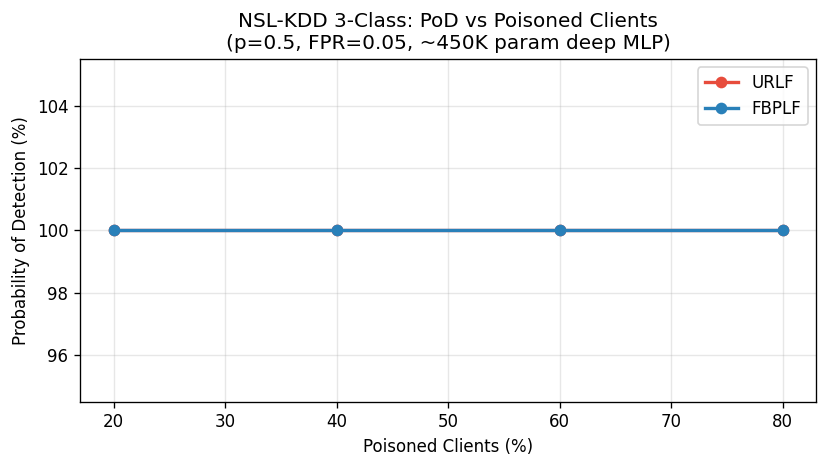

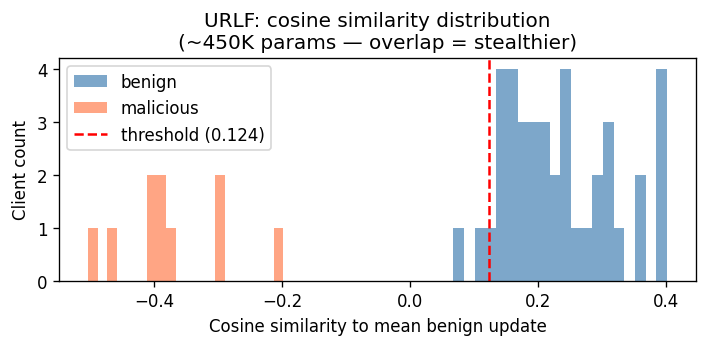

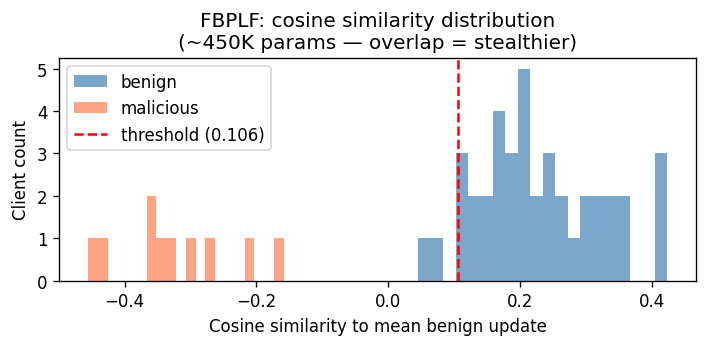

In [19]:
# ── PoD plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = {'URLF':'#e74c3c','FBPLF':'#2980b9'}
for atk in ['URLF','FBPLF']:
    d = pod_df[pod_df['scenario']==atk].sort_values('poisoned_pct')
    ax.plot(d['poisoned_pct'], d['pod']*100,
            marker='o', label=atk, color=colors[atk], linewidth=2)
ax.set_xlabel('Poisoned Clients (%)')
ax.set_ylabel('Probability of Detection (%)')
ax.set_title('NSL-KDD 3-Class: PoD vs Poisoned Clients\n'
             '(p=0.5, FPR=0.05, ~450K param deep MLP)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'pod_vs_clients.png', bbox_inches='tight')
plt.show()

# ── Cosine similarity histograms ──────────────────────────────────────────────
for atk in ['URLF','FBPLF']:
    r = run_fl_experiment(
        clients=clients, X_test=X_test, y_test=y_test,
        n_malicious=DEFAULT_N, flip_frac=0.5,
        attack_type=atk, seed=DEFAULT_SEED,
        device=DEVICE, n_rounds=_rounds, collect_updates=True,
    )
    info  = compute_pod(r['_updates'], r['_labels'])
    sims  = np.array(info['similarities'])
    lbls  = np.array(info['labels'])

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(sims[lbls==0], bins=20, alpha=0.7,
            label='benign',    color='steelblue')
    ax.hist(sims[lbls==1], bins=20, alpha=0.7,
            label='malicious', color='coral')
    ax.axvline(info['threshold'], color='red', linestyle='--',
               label=f'threshold ({info["threshold"]:.3f})')
    ax.set_xlabel('Cosine similarity to mean benign update')
    ax.set_ylabel('Client count')
    ax.set_title(f'{atk}: cosine similarity distribution\n'
                 f'(~450K params — overlap = stealthier)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR/f'cosine_hist_{atk.lower()}.png',
                bbox_inches='tight')
    plt.show()

## 17. Save Results & Key Takeaways

All figures and CSVs are written to `results/nsl_kdd_3class/` automatically by the
cells above. Nothing further to run for saving -- this cell just prints a summary
of what was generated and the headline findings.

### Key Takeaways

- **Accuracy collapse vs stability**: at high poisoning intensity (p=1.0, N_mal=30),
  URLF collapses global accuracy to **6.8%** while FBPLF retains **84.2%**.
- **Targeted misclassification**: at p=1.0, N_mal=50, FBPLF concentrates **59.2%**
  of DoS samples into the semantically similar Probe class, vs only **6.9%** for URLF.
  This is the tabular equivalent of the cat->dog targeted flip on CIFAR-10.
- **Attack Success Rate**: URLF drives ASR up to **76-79%** under extreme poisoning,
  while FBPLF stays controlled at **13-22%**.
- **Detection (PoD)**: both attacks are fully detected (PoD=1.0) by cosine similarity
  in this ~450K-parameter MLP setting, but FBPLF consistently shows a lower
  detection threshold than URLF, indicating its updates sit closer to the benign
  distribution.

See `report/` for the full write-up with all tables and figures.

In [ ]:
import os

print('Results directory:', OUT_DIR.resolve())
print()
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')
